In [3]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 2. loading the data file 
df = pd.read_csv('Documents/diabetes_prediction_dataset.csv')
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (100000, 9)
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [6]:
#Exploring data
print("\nDataset info:")
print("\ninfo:\n")
print(df.info())
print("\nDescribe:\n")
print(df.describe())

#checking the null values
print("\nMissing Values:\n", df.isnull().sum())


Dataset info:

info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

Describe:

                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840    

In [5]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [16]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,0,80.0,0,0,0,27.32,6.2,90,0
99996,0,2.0,0,0,0,17.37,6.5,100,0
99997,1,66.0,0,0,3,27.83,5.7,155,0
99998,0,24.0,0,0,4,35.42,4.0,100,0
99999,0,57.0,0,0,1,22.43,6.6,90,0


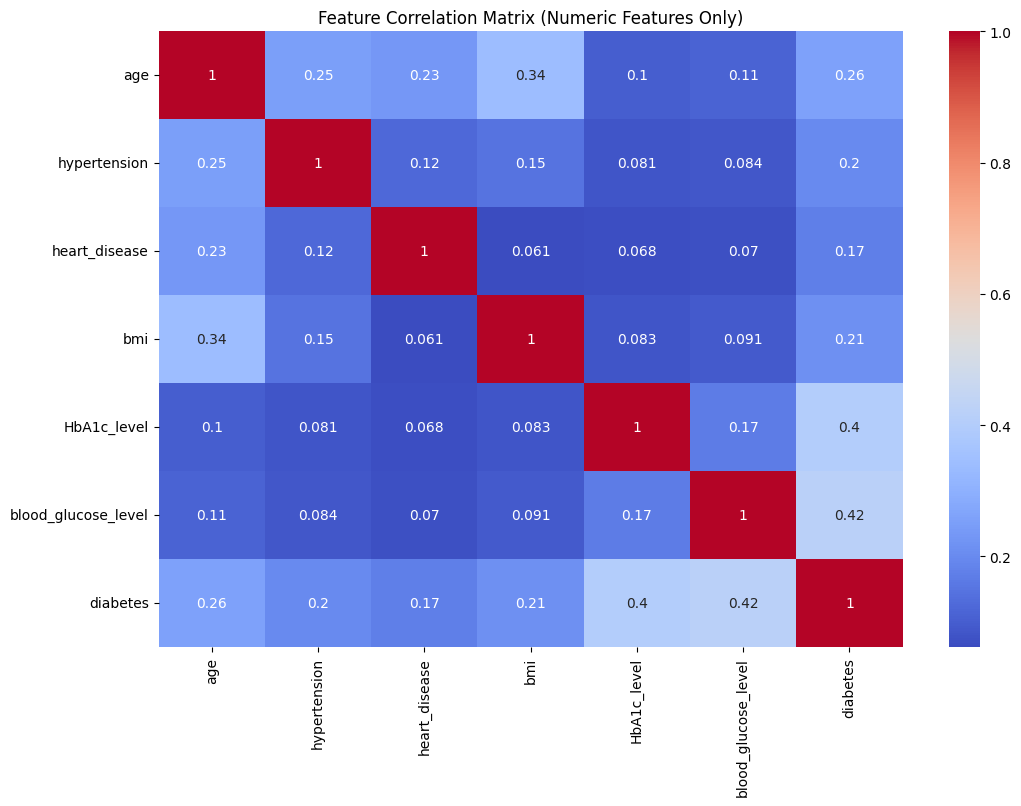

In [8]:
# Selection of  numeric columns only
numeric_df = df.select_dtypes(include=['number'])

# Now I am computing correlation and plot
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix (Numeric Features Only)")
plt.show()

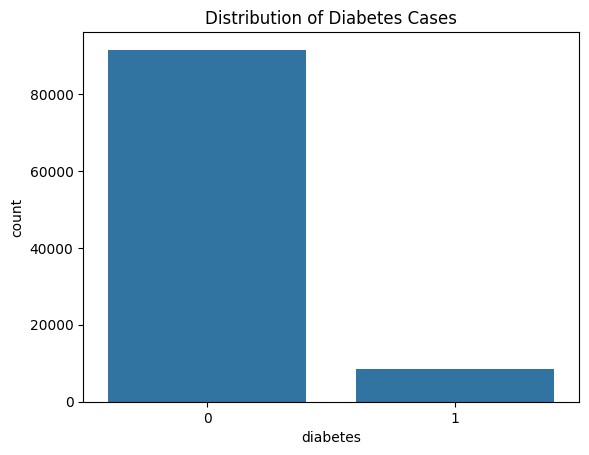

In [9]:
# Distribution of target variable
sns.countplot(x='diabetes', data=df)
plt.title("Distribution of Diabetes Cases")
plt.show()

In [10]:
# preprocessing, in this dataset 0 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode categorical columns if any
categorical_cols = df.select_dtypes(include='object').columns

# applying Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and Target
X = df.drop('diabetes', axis=1)
y = df['diabetes']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# selecting Random Forest
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Define pipeline
pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('model', RandomForestClassifier(random_state=42))])

In [12]:
# Helper function to evaluate a model - more faster for creating a confusion matrix
def evaluate_model(model, X_test, y_test, title="Confusion Matrix"):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
    y_pred = model.predict(X_test)
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
    plt.title(title)
    plt.show()



Before Hyperparameter Tuning:
Accuracy: 0.9700
Precision: 0.9435
Recall: 0.6882
F1 Score: 0.7959


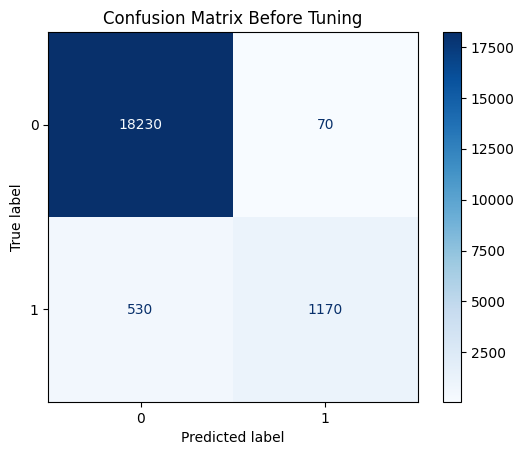


Starting GridSearchCV...
Grid Search Completed.

Best Parameters Found:
{'model__max_depth': 20, 'model__min_samples_split': 10, 'model__n_estimators': 200}

After Hyperparameter Tuning:
Accuracy: 0.9719
Precision: 0.9806
Recall: 0.6835
F1 Score: 0.8055


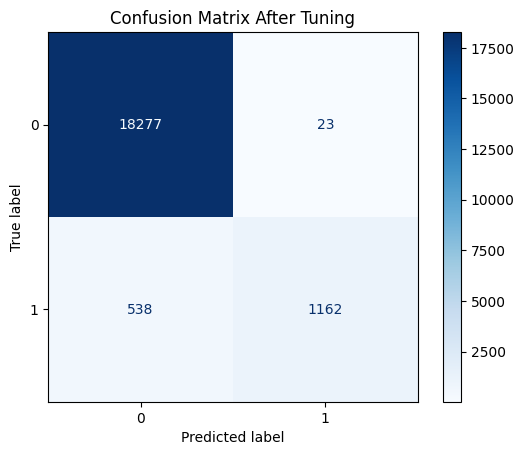

In [13]:
# Evaluation before tuning
print("\nBefore Hyperparameter Tuning:")
evaluate_model(pipeline, X_test, y_test, title="Confusion Matrix Before Tuning")

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10]
}

print("\nStarting GridSearchCV...")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Grid Search Completed.")

# Best parameters
print("\nBest Parameters Found:")
print(grid_search.best_params_)


#Evaluation after tuning
print("\nAfter Hyperparameter Tuning:")
best_model = grid_search.best_estimator_
evaluate_model(best_model, X_test, y_test, title="Confusion Matrix After Tuning")


In [15]:
#summarizing the overall my findings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Collecting the results
summary = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Before Tuning": [
        accuracy_score(y_test, pipeline.predict(X_test)),
        precision_score(y_test, pipeline.predict(X_test)),
        recall_score(y_test, pipeline.predict(X_test)),
        f1_score(y_test, pipeline.predict(X_test))
    ],
    "After Tuning": [
        accuracy_score(y_test, best_model.predict(X_test)),
        precision_score(y_test, best_model.predict(X_test)),
        recall_score(y_test, best_model.predict(X_test)),
        f1_score(y_test, best_model.predict(X_test))
    ]
}

# Created the dataframe
summary_df = pd.DataFrame(summary)
summary_df

,Metric,Before Tuning,After Tuning
0,Accuracy,0.970000,0.971950
1,Precision,0.943548,0.980591
2,Recall,0.688235,0.683529
3,F1 Score,0.795918,0.805546
